# SVT Analysis
Notebook for quick SVT experiments and visualization.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns
import numpy as np

PROJECT_ROOT = Path.cwd().parent
IMAGE_PATH = Path(PROJECT_ROOT) / "data" / "CBSD68"
NETFLIX_PATH = Path(PROJECT_ROOT) / "data" / "netflix"
RESULTS_PATH = Path(PROJECT_ROOT) / "results" / "svt" / "images"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.svt.svt import svt
from src.utils.masking import create_mask, apply_mask, create_netflix_mask
from src.utils.noise import add_gaussian_noise, add_pairflip_noise, add_symmetric_noise
from src.utils.io import load_image, load_netflix_matrix
from src.utils.metrics import mse, nmse, psnr

from experiments.config import *

## Images

In [5]:
rec = pd.read_csv(RESULTS_PATH / "reconstruction.csv")
den = pd.read_csv(RESULTS_PATH / "denoising.csv")

rec_avg = rec.groupby("sparsity")["PSNR"].mean()
den_avg = den.groupby("sigma")["PSNR"].mean()
rec_std = rec.groupby("sparsity")["PSNR"].std()
den_std = den.groupby("sigma")["PSNR"].std()

print(f"Reconstruction Observed Fraction vs. PSNR: {rec_avg}")
print(f"Denoising Noise Level vs. PSNR: {den_avg}")
print(f"Reconstruction PSNR Std Dev: {rec_std}")
print(f"Denoising PSNR Std Dev: {den_std}")

Reconstruction Observed Fraction vs. PSNR: sparsity
0.2    26.867388
0.4    18.854214
0.6    13.640453
Name: PSNR, dtype: float64
Denoising Noise Level vs. PSNR: sigma
0.05    27.213737
0.10    21.750301
0.20    15.041762
Name: PSNR, dtype: float64
Reconstruction PSNR Std Dev: sparsity
0.2    4.143443
0.4    3.685494
0.6    3.049806
Name: PSNR, dtype: float64
Denoising PSNR Std Dev: sigma
0.05    1.770182
0.10    0.738387
0.20    0.470938
Name: PSNR, dtype: float64


In [2]:
def show_results(X, X_rec, X_noisy=None, X_masked=None, title=""):
    plt.figure(figsize=(12, 4))

    if X_noisy is not None:
        plt.subplot(1, 3, 1)
        plt.imshow(X, cmap="gray", vmin=0, vmax=1)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(X_noisy, cmap='gray', vmin=0, vmax=1)
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(X_rec, cmap="gray", vmin=0, vmax=1)
        plt.title("Denoised")
        plt.axis("off")

    else:
        plt.subplot(1, 3, 1)
        plt.imshow(X, cmap='gray', vmin=0, vmax=255)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(X_masked, cmap='gray', vmin=0, vmax=255)
        plt.title("Observed pixels")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(X_rec, cmap='gray', vmin=0, vmax=255)
        plt.title("Reconstructed")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

In [7]:
# Reconstruction
X = load_image(IMAGE_PATH / "0047.png")
X = X[:256, :256]
print(X.min(), X.max(), X.dtype)

n1, n2 = X.shape
missing_fraction = 0.4
observed_fraction = 1 - missing_fraction

tau = 8 * max(n1, n2) # tau = 8 * 256 = 2048  -> try 6, 7, 8  for tau factor?
# print(np.mean(X))
delta = DELTA_FACTOR # delta = 1.2 / 0.8 = 1.5

mask = create_mask(X.shape, observed_fraction, seed=SEED)
Omega, b = apply_mask(X, mask)

X_masked = np.zeros_like(X)
X_masked[Omega] = b

38.0 195.0 float64


Converged at iteration 287 with rank 186 and relative error 0.000010
Final rank: 186, final relative error: 0.000010
NMSE: 0.00488663965180134
PSNR: 23.109896853230193


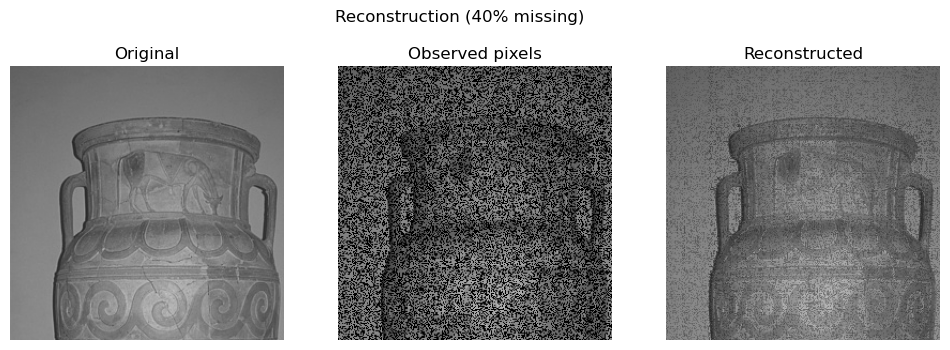

In [8]:
X_rec, hist = svt(X.shape, Omega, b, tau, delta)
# print(np.max(X_rec), np.min(X_rec))
X_rec = np.clip(X_rec, 0, 255)

print("NMSE:", nmse(X, X_rec, data_range=255))
print("PSNR:", psnr(X, X_rec, data_range=255))

show_results(X, X_rec, X_masked=X_masked, title=f"Reconstruction ({missing_fraction*100:.0f}% missing)")

In [15]:
# count how many False values in the mask
m = np.sum(~mask)
print(f"Number of missing pixels: {m} out of {X.size} ({m/X.size:.2%} missing)")

Number of missing pixels: 61835 out of 154401 (40.05% missing)


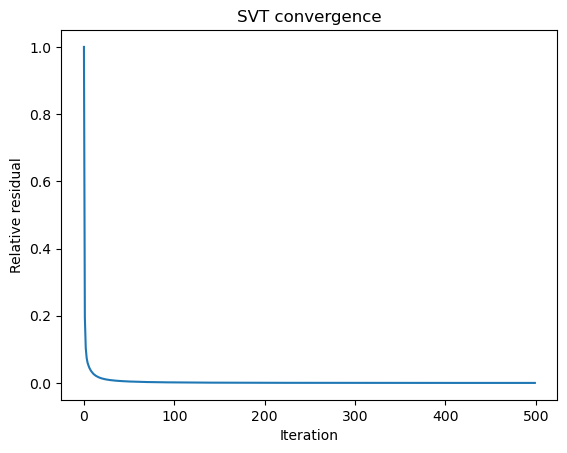

In [5]:
# Check if the residual decreases monotonically
plt.plot(hist["residual"])
plt.title("SVT convergence")
plt.xlabel("Iteration")
plt.ylabel("Relative residual")
plt.show()

Text(0.5, 1.0, 'Image singular value decay')

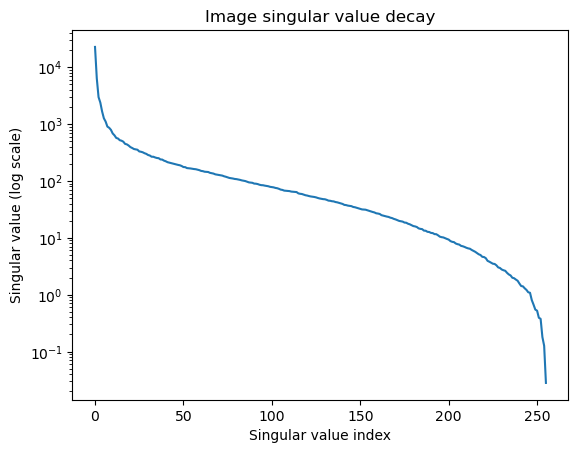

In [94]:
# Check if the singular values decay rapidly
U, S, Vt = np.linalg.svd(X, full_matrices=False)
plt.semilogy(S)
plt.xlabel("Singular value index")
plt.ylabel("Singular value (log scale)")
plt.title("Image singular value decay")

Final rank: 66, final relative error: 0.133045
NMSE: 0.006527084250122155
PSNR: 21.852807814932365


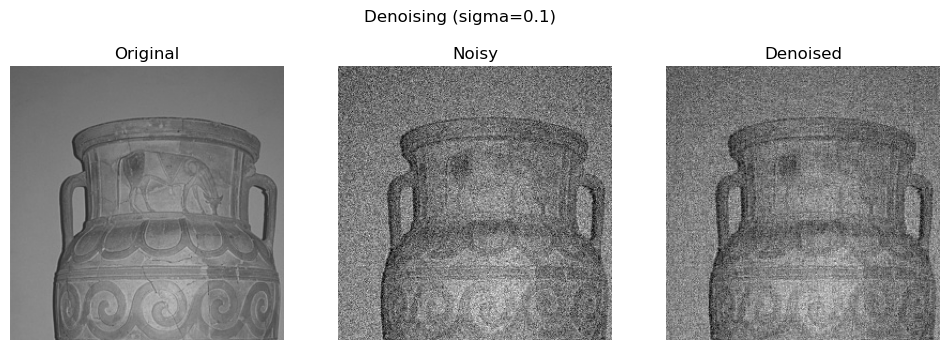

In [3]:
# Denoising
X = load_image(IMAGE_PATH / "0047.png", normalize=True)
X = X[:256, :256]

# sigma = 0.1 * 255  # sigma = 0.1 * 255 = 25.5
sigma = 0.1  # sigma = 0.1 in [0,1] range
X_noisy = add_gaussian_noise(X, sigma=sigma, normalize=True)

n1, n2 = X.shape
# tau = 2 * sigma * max(n1, n2)
tau = TAU_FACTOR * max(n1, n2) # tau = 5 * 256 = 1536
delta = DELTA_FACTOR

Omega = np.where(np.ones_like(X, dtype=bool))
b = X_noisy[Omega]

X_denoised, _ = svt(X.shape, Omega, b, tau, delta)
X_denoised = np.clip(X_denoised, 0, 1)

print("NMSE:", nmse(X, X_denoised, data_range=1.0))
print("PSNR:", psnr(X, X_denoised, data_range=1.0))

show_results(X, X_denoised, X_noisy=X_noisy, title="Denoising (sigma=0.1)")

### Patch-based SVT

#### Image Reconstruction

In [14]:
# Overlapping patch extraction and reconstruction
def extract_patches(X, patch_size, stride):

    patches = []
    positions = []

    h, w = X.shape

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):

            patch = X[i:i+patch_size, j:j+patch_size]

            patches.append(patch)
            positions.append((i, j))

    return patches, positions

def reconstruct_from_patches(patches, positions, image_shape, patch_size):

    X = np.zeros(image_shape)
    weight = np.zeros(image_shape)

    for patch, (i, j) in zip(patches, positions):

        X[i:i+patch_size, j:j+patch_size] += patch
        weight[i:i+patch_size, j:j+patch_size] += 1

    return X / weight

In [15]:
def svt_patch_completion(X, mask, patch_size=32, stride=16):

    patches, positions = extract_patches(X, patch_size, stride)
    mask_patches, _ = extract_patches(mask.astype(float), patch_size, stride)

    rec_patches = []

    for patch, patch_mask in zip(patches, mask_patches):

        Omega = np.where(patch_mask)
        b = patch[Omega]

        tau = 8 * patch_size
        delta = 1.2

        X_rec, _ = svt(patch.shape, Omega, b, tau, delta)

        rec_patches.append(X_rec)

    return reconstruct_from_patches(
        rec_patches,

        positions,
        X.shape,
        patch_size
    )

In [16]:
X = load_image(IMAGE_PATH / "0047.png", normalize=True)
X = X[:256, :256]

n1, n2 = X.shape
missing_fraction = 0.4
observed_fraction = 1 - missing_fraction

mask = create_mask(X.shape, observed_fraction, seed=SEED)

X_masked = np.zeros_like(X)
X_masked[mask] = X[mask]

X_rec = svt_patch_completion(X, mask)

Final rank: 1, final relative error: 0.008928
Final rank: 1, final relative error: 0.008375
Final rank: 1, final relative error: 0.008061
Final rank: 1, final relative error: 0.008686
Final rank: 1, final relative error: 0.008239
Final rank: 1, final relative error: 0.007046
Final rank: 1, final relative error: 0.007390
Final rank: 1, final relative error: 0.007543
Final rank: 1, final relative error: 0.007959
Final rank: 1, final relative error: 0.008549
Final rank: 1, final relative error: 0.008642
Final rank: 1, final relative error: 0.007997
Final rank: 1, final relative error: 0.008051
Final rank: 1, final relative error: 0.009056
Final rank: 1, final relative error: 0.007792
Final rank: 1, final relative error: 0.009778
Final rank: 1, final relative error: 0.008436
Final rank: 1, final relative error: 0.008189
Final rank: 1, final relative error: 0.007543
Final rank: 1, final relative error: 0.006820
Final rank: 1, final relative error: 0.005997
Final rank: 1, final relative erro

NMSE: 0.0007979515511198365
PSNR: 30.98023476719531


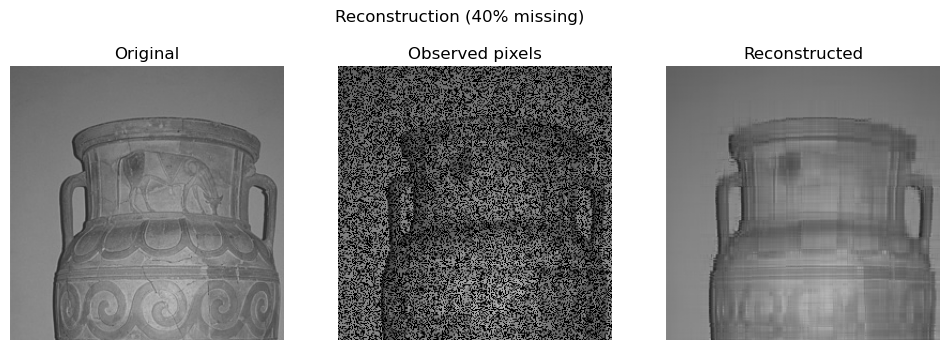

In [19]:
print("NMSE:", nmse(X, X_rec, data_range=1.0))
print("PSNR:", psnr(X, X_rec, data_range=1.0))

show_results(X, X_rec, X_masked=X_masked, title=f"Reconstruction ({missing_fraction*100:.0f}% missing)")

#### Image Denoising

In [12]:
def svt_patch_denoising(X_noisy, patch_size=32, stride=16, tau_factor=TAU_FACTOR, delta=DELTA_FACTOR):
    patches, positions = extract_patches(X_noisy, patch_size, stride)

    denoised_patches = []

    for patch in patches:
        # For denoising, every pixel is observed in each noisy patch.
        Omega = np.where(np.ones_like(patch, dtype=bool))
        b = patch[Omega]

        tau = tau_factor * patch_size
        X_patch_denoised, _ = svt(patch.shape, Omega, b, tau, delta)

        denoised_patches.append(X_patch_denoised)

    return reconstruct_from_patches(
        denoised_patches,
        positions,
        X_noisy.shape,
        patch_size
    )

X = load_image(IMAGE_PATH / "0065.png", normalize=True)
X = X[:256, :256]

sigma = 0.1
X_noisy = add_gaussian_noise(X, sigma=sigma, normalize=True)

X_denoised_patch = svt_patch_denoising(
    X_noisy,
    patch_size=32,
    stride=16,
    tau_factor=TAU_FACTOR,
    delta=DELTA_FACTOR
)

Final rank: 25, final relative error: 0.024891
Final rank: 24, final relative error: 0.024725
Final rank: 24, final relative error: 0.023033
Final rank: 24, final relative error: 0.031947
Final rank: 23, final relative error: 0.030185
Final rank: 25, final relative error: 0.020515
Final rank: 24, final relative error: 0.022887
Final rank: 23, final relative error: 0.031670
Final rank: 24, final relative error: 0.034599
Final rank: 22, final relative error: 0.060918
Final rank: 21, final relative error: 0.097670
Final rank: 21, final relative error: 0.090415
Final rank: 22, final relative error: 0.084695
Final rank: 23, final relative error: 0.075758
Final rank: 21, final relative error: 0.099426
Final rank: 23, final relative error: 0.034266
Final rank: 23, final relative error: 0.027788
Final rank: 24, final relative error: 0.025760
Final rank: 24, final relative error: 0.024899
Final rank: 24, final relative error: 0.023645
Final rank: 24, final relative error: 0.025550
Final rank: 2

Patch-SVT Denoising NMSE: 0.009428577255705388
Patch-SVT Denoising PSNR: 20.255538360657308


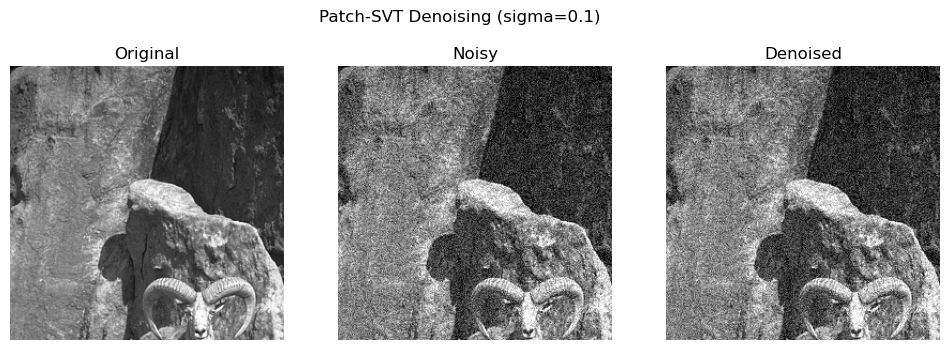

In [13]:
print("Patch-SVT Denoising NMSE:", nmse(X, X_denoised_patch, data_range=1.0))
print("Patch-SVT Denoising PSNR:", psnr(X, X_denoised_patch, data_range=1.0))

show_results(
    X,
    X_denoised_patch,
    X_noisy=X_noisy,
    title=f"Patch-SVT Denoising (sigma={sigma})"
)

## Recommender System Dataset

In [2]:
df = pd.read_csv(NETFLIX_PATH / "netflix_dense_mtx_0_925_256_movies.csv", index_col=0)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
0,1,3,2,4,2,2,3,4,1,3,...,2,0,4,5,3,1,4,2,0,2
1,4,4,3,0,5,0,3,4,4,3,...,0,3,0,4,4,5,3,3,4,0
2,3,5,5,4,5,3,5,0,4,5,...,5,3,5,5,5,5,5,3,5,5
3,4,0,4,4,4,3,4,5,4,4,...,4,3,4,5,4,4,4,4,4,4
4,4,2,4,5,4,4,2,4,2,3,...,1,0,3,3,3,1,0,4,5,5


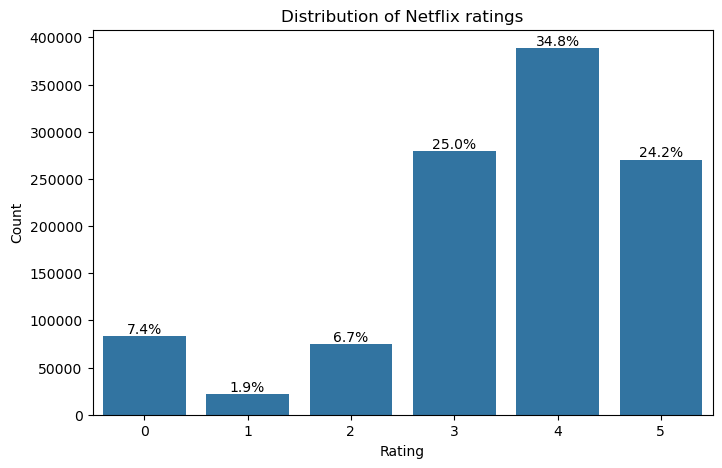

In [ ]:
# visualize distribution of ratings with shown percentages
plt.figure(figsize=(8, 5))
sns.countplot(x=df.values.flatten(), order=range(6))
# add percentages on top of bars
total = len(df.values.flatten())
for p in plt.gca().patches:
    height = p.get_height()
    percentage = height / total * 100
    plt.gca().text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Netflix ratings")
plt.show()

In [3]:
# Crop df to 256x256 selecting the contiguous 256-row block with minimum zeros
window = 256
assert df.shape[1] >= window, "DataFrame has fewer than 256 columns."

zeros_per_row = (df.iloc[:, :window] == 0).sum(axis=1).to_numpy()
cs = zeros_per_row.cumsum()
# sliding window sums of zeros for each possible start row
window_sums = cs[window - 1:] - np.concatenate(([0], cs[:-window]))
best_start = int(np.argmin(window_sums))
min_zeros = int(window_sums[best_start])

df = df.iloc[best_start:best_start + window, :window].copy()
print(f"Selected rows {best_start}:{best_start + window}, zero count in block: {min_zeros}")

Selected rows 1225:1481, zero count in block: 4546


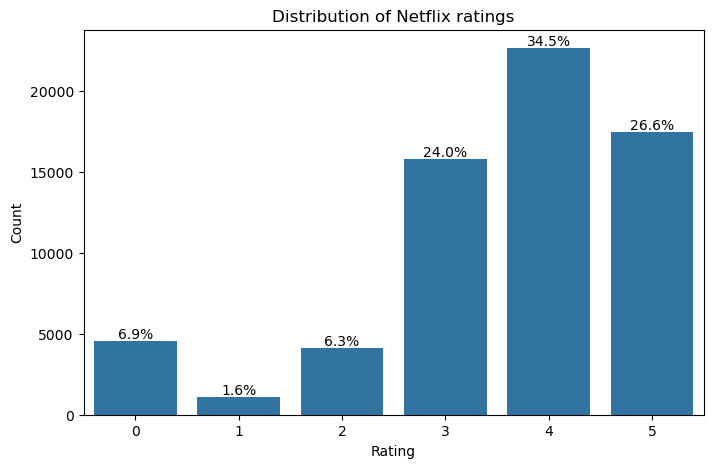

In [6]:
# visualize distribution of ratings with shown percentages
plt.figure(figsize=(8, 5))
sns.countplot(x=df.values.flatten(), order=range(6))
# add percentages on top of bars
total = len(df.values.flatten())
for p in plt.gca().patches:
    height = p.get_height()
    percentage = height / total * 100
    plt.gca().text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Netflix ratings")
plt.show()

In [8]:
# save df in the same format as the original (include index)
df.reset_index(drop=True).to_csv(NETFLIX_PATH / "netflix_dense_mtx_small.csv", index=True)

In [2]:
X, original_mask = load_netflix_matrix(
            NETFLIX_PATH / "netflix_dense_mtx_0_925_256_movies.csv"
    )

Text(0, 0.5, 'Singular value (log scale)')

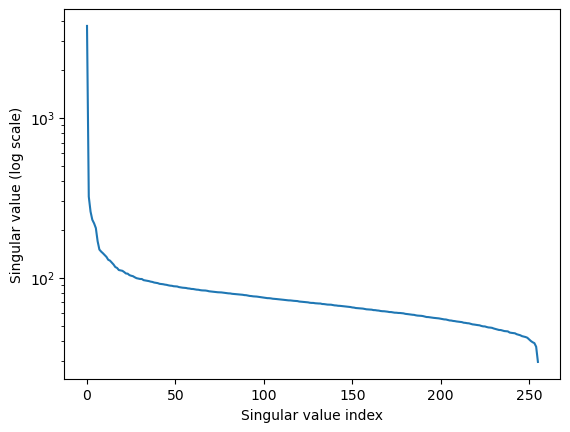

In [3]:
s = np.linalg.svd(X, compute_uv=False)
plt.semilogy(s)
plt.xlabel("Singular value index")
plt.ylabel("Singular value (log scale)")

In [19]:
# Effective rank: how many singular values are needed to capture 90% of the energy?
s = np.linalg.svd(X, compute_uv=False)
energy = np.cumsum(s**2)/np.sum(s**2)
r90 = np.searchsorted(energy,0.90)+1
print(r90)

3


In [6]:
original_mask

array([[ True,  True,  True, ...,  True, False,  True],
       [ True,  True,  True, ...,  True,  True, False],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True, False, ...,  True,  True,  True],
       [ True,  True, False, ...,  True,  True,  True]], shape=(4367, 256))

In [5]:
# count how many False values in the mask
m = np.sum(~original_mask)
print(f"Number of missing entries: {m} out of {X.size} ({m/X.size:.2%} missing)")

Number of missing entries: 83229 out of 1117952 (7.44% missing)


In [3]:
# Reconstruction experiment with 40% missing

# 1: Start with real observed Netflix matrix with 92.5% observed entries
n1, n2 = X.shape
# tau = TAU_FACTOR * np.sqrt(n1 * n2)
tau = TAU_FACTOR * max(n1, n2) # tau = 5 * 4367 = 21835
missing_fraction = 0.4
observed_fraction = 1 - missing_fraction
delta = DELTA_FACTOR / observed_fraction
# 2: Create random reduced observation set
mask = create_netflix_mask(original_mask, observed_fraction, seed=SEED)

# 3: Run SVT using only P_Omega(X)
Omega, b = apply_mask(X, mask) # obtain observed entries based on the new mask to obtain Omega_train and b_train
X_rec, _ = svt((n1, n2), Omega, b, tau, delta) # reconstruct the matrix using SVT with the Omega_train and b_train
X_rec = np.clip(X_rec, 1, 5) # clip to valid rating range

# 4: Evaluate reconstruction quality
test_mask = original_mask & (~mask) # evaluate on hidden entries that were originally observed but not included in the training mask

Final rank: 232, final relative error: 0.024131


In [4]:
mse_val = np.mean((X[test_mask] - X_rec[test_mask]) ** 2)
psnr_val = psnr(X[test_mask], X_rec[test_mask], data_range=4.0)
rmse = np.sqrt(np.mean((X[test_mask] - X_rec[test_mask]) ** 2))
nrmse = rmse / 4.0  # divide by 4
mae = np.mean(np.abs(X[test_mask] - X_rec[test_mask]))

print(
        "Reconstruction for {}% observed entries:".format(int(observed_fraction * 100))
    )
print("MSE:", mse_val)
print("PSNR:", psnr_val)
print("RMSE:", rmse)
print("NRMSE:", nrmse)
print("MAE:", mae)

Reconstruction for 60% observed entries:
MSE: 0.5792483189490026
PSNR: 14.412552005689331
RMSE: 0.7610836478002945
NRMSE: 0.19027091195007362
MAE: 0.5950706247453281


Observed: 80%, Tau: 5 * max(n1, n2), Iter: 1000 => Rank: 256, RMSE: 0.738

Observed: 60%, Tau: 5 * max(n1, n2), Iter: 1000 => Rank: 256, RMSE: 0.754

Observed: 60%, Tau: 5 * max(n1, n2), Iter: 500 => Rank: 232, RMSE: 0.761


Observed: 60%, Tau: 10 * max(n1, n2), Iter: 500 => Rank: 37, RMSE: 0.773

Observed: 60%, Tau: 15 * max(n1, n2), Iter: 500 => Rank: 6, RMSE: 0.7697

Observed: 60%, Tau: 15 * max(n1, n2), Iter: 1000 => Rank: 125, RMSE: 0.7899

In [6]:
X_rec_round = np.clip(np.rint(X_rec), 1, 5)

In [9]:
mse_val = np.mean((X[test_mask] - X_rec_round[test_mask]) ** 2)
psnr_val = psnr(X[test_mask], X_rec_round[test_mask], data_range=4.0)
rmse = np.sqrt(np.mean((X[test_mask] - X_rec_round[test_mask]) ** 2))
nrmse = rmse / 4.0  # divide by 4
mae = np.mean(np.abs(X[test_mask] - X_rec_round[test_mask]))

print(
        "Reconstruction for {}% observed entries:".format(int(observed_fraction * 100))
    )
print("MSE:", mse_val)
print("PSNR:", psnr_val)
print("RMSE:", rmse)
print("NRMSE:", nrmse)
print("MAE:", mae)

Reconstruction for 60% observed entries:
MSE: 0.6626163704509733
PSNR: 13.828578213956774
RMSE: 0.8140125124658547
NRMSE: 0.20350312811646368
MAE: 0.5476121387982106


RMSE (Rounded X rec): 0.814; MAE (Rounded X rec): 0.5476

RMSE (Unrounded with rint): 0.7611; MAE (Unrounded): 0.5951

In [7]:
# Denoising experiment with 10% pairflip noise on the observed entries

# 1: Start with real observed Netflix matrix with 92.5% observed entries
n1, n2 = X.shape
tau = TAU_FACTOR * max(n1, n2) # tau = 5 * 4367 = 21835
delta = DELTA_FACTOR

# 2: Corrupt the dataset
Y, flip_mask = add_pairflip_noise(X, original_mask, prob=0.1) # add pairflip noise to the observed entries in X to create Y
Omega = np.where(original_mask)  # use observed entries
b = Y[Omega]


In [8]:
np.sum(flip_mask)/X.size

np.float64(0.09267481967025418)

In [ ]:
# 3: Run recovery using SVT
X_rec, _ = svt((n1, n2), Omega, b, tau, delta)
X_rec = np.clip(X_rec, 1, 5)

In [60]:
rmse_noisy = np.sqrt(
np.mean((X[original_mask]-Y[original_mask])**2)
)
print("Noisy observed entries RMSE:", rmse_noisy)

Noisy observed entries RMSE: 0.2935767663920932


In [59]:
rmse = np.sqrt(np.mean(
        (X[original_mask] - X_rec[original_mask]) ** 2
    ))
print("Denoising with 10% pairflip noise on observed entries:")
print(f"RMSE: {rmse:.4f}")

Denoising with 10% pairflip noise on observed entries:
RMSE: 0.6081


In [61]:
rmse_corrupted_before = np.sqrt(
np.mean((X[flip_mask]-Y[flip_mask])**2)
)
print("Corrupted entries RMSE (before denoising):", rmse_corrupted_before)

rmse_corrupted_after = np.sqrt(
np.mean((X[flip_mask]-X_rec[flip_mask])**2)
)
print("Corrupted entries RMSE (after denoising):", rmse_corrupted_after)

Corrupted entries RMSE (before denoising): 0.9267930409306889
Corrupted entries RMSE (after denoising): 0.6654436781779414


Noise: 10%, Tau: 5 * np.sqrt(n1 * n2), Iter: 1000 => Converged at iter 569, Rank: 256, RMSE: 0.2934, Noisy observed RMSE: 0.2934

Noise: 10%, Tau: 5 * max(n1, n2), Iter: 500 => 
    Rank: 222, RMSE: 0.3195, Noisy observed RMSE: 0.2927, Corrupted entries RMSE (before denoising): 0.9272,
    Corrupted entries RMSE (after denoising): 0.8647
    
Noise: 10%, Tau: 8 * max(n1, n2), Iter: 500 => 
    Rank: 47, RMSE: 0.608, Noisy observed RMSE: 0.293, Corrupted entries RMSE (before denoising): 0.9267930409306889, Corrupted entries RMSE (after denoising): 0.6654436781779414


In [ ]:
# Denoising experiment with symmetric noise on the observed entries

# 1: Start with real observed Netflix matrix with 92.5% observed entries
n1, n2 = X.shape
tau = 7 * max(n1, n2) # tau = 5 * 4367 = 21835
delta = DELTA_FACTOR

# 2: Corrupt the dataset
Y, flip_mask = add_symmetric_noise(X, original_mask, prob=0.1) # add symmetric noise to the observed entries in X to create Y
Omega = np.where(original_mask)  # use observed entries
b = Y[Omega]


In [14]:
np.sum(flip_mask)/X.size

np.float64(0.09276069097778795)

In [19]:
rmse_corrupted_before = np.sqrt(
np.mean((X[flip_mask]-Y[flip_mask])**2)
)
print("Corrupted entries RMSE (before denoising):", rmse_corrupted_before)
rmse_noisy = np.sqrt(
np.mean((X[original_mask]-Y[original_mask])**2)
)
print("Noisy observed entries RMSE:", rmse_noisy)

Corrupted entries RMSE (before denoising): 2.1224414219214607
Noisy observed entries RMSE: 0.6720069381909903


In [20]:
# 3: Run recovery using SVT
X_rec, _ = svt((n1, n2), Omega, b, tau, delta)
X_rec = np.clip(X_rec, 1, 5)

Final rank: 111, final relative error: 0.154232


In [21]:
rmse = np.sqrt(np.mean(
        (X[original_mask] - X_rec[original_mask]) ** 2
    ))
print("Denoising with 10% symmetric noise on observed entries:")
print(f"RMSE: {rmse:.4f}")

rmse_corrupted_after = np.sqrt(
np.mean((X[flip_mask]-X_rec[flip_mask])**2)
)
print("Corrupted entries RMSE (after denoising):", rmse_corrupted_after)

Denoising with 10% symmetric noise on observed entries:
RMSE: 0.6666
Corrupted entries RMSE (after denoising): 1.4147146910841046


Symmetric noise: 10%, Tau: 5 * max(n1, n2), Iter: 500 => 
    Rank: 256, RMSE: 0.6678, Noisy observed RMSE: 0.668, Corrupted entries RMSE (before denoising): 2.1097, Corrupted entries RMSE (after denoising): 2.109

Symmetric noise: 10%, Tau: 7 * max(n1, n2), Iter: 500 => 
    Rank: 179, RMSE: 0.6600, Noisy observed RMSE: 0.6701, Corrupted entries RMSE (before denoising): 2.1167, Corrupted entries RMSE (after denoising): 1.77998
    
Symmetric noise: 10%, Tau: 8 * max(n1, n2), Iter: 500 => 
    Rank: 111, RMSE: 0.6666, Noisy observed RMSE: 0.6720, Corrupted entries RMSE (before denoising): 2.1224, Corrupted entries RMSE (after denoising): 1.4147

Small Netflix Dataset experiments 

In [2]:
X, original_mask = load_netflix_matrix(
            NETFLIX_PATH / "netflix_dense_mtx_small.csv"
)

In [10]:
# Reconstruction experiment with 40% missing

# 1: Start with real observed Netflix matrix with 92.5% observed entries
n1, n2 = X.shape
# tau = TAU_FACTOR * np.sqrt(n1 * n2)
tau = TAU_FACTOR * max(n1, n2) # tau = 5 * 4367 = 21835
missing_fraction = 0.4
observed_fraction = 1 - missing_fraction
delta = DELTA_FACTOR / observed_fraction
# 2: Create random reduced observation set
mask = create_netflix_mask(original_mask, observed_fraction, seed=SEED)

# 3: Run SVT using only P_Omega(X)
Omega, b = apply_mask(X, mask) # obtain observed entries based on the new mask to obtain Omega_train and b_train
X_rec, _ = svt((n1, n2), Omega, b, tau, delta) # reconstruct the matrix using SVT with the Omega_train and b_train
X_rec = np.clip(X_rec, 1, 5) # clip to valid rating range

# 4: Evaluate reconstruction quality
test_mask = original_mask & (~mask) # evaluate on hidden entries that were originally observed but not included in the training mask

mse_val = np.mean((X[test_mask] - X_rec[test_mask]) ** 2)
psnr_val = psnr(X[test_mask], X_rec[test_mask], data_range=4.0)
rmse = np.sqrt(np.mean((X[test_mask] - X_rec[test_mask]) ** 2))
nrmse = rmse / 4.0  # divide by 4
mae = np.mean(np.abs(X[test_mask] - X_rec[test_mask]))

print(
        "Reconstruction for {}% observed entries:".format(int(observed_fraction * 100))
    )
print("MSE:", mse_val)
print("PSNR:", psnr_val)
print("RMSE:", rmse)
print("NRMSE:", nrmse)
print("MAE:", mae)

Final rank: 162, final relative error: 0.002568
Reconstruction for 60% observed entries:
MSE: 0.7523088391220276
PSNR: 13.277238181391834
RMSE: 0.8673573883480947
NRMSE: 0.21683934708702368
MAE: 0.6797928462557475


Reconstruction on Netflix dataset with 60% observed entries:
- rectangular matrix: 0.7611 RMSE
- small square matrix: 0.8674 RMSE

In [3]:
# Denoising experiment with symmetric noise on the observed entries

# 1: Start with real observed Netflix matrix with 92.5% observed entries
n1, n2 = X.shape
tau = 7 * max(n1, n2) # tau = 5 * 4367 = 21835
delta = DELTA_FACTOR

# 2: Corrupt the dataset
Y, flip_mask = add_symmetric_noise(X, original_mask, prob=0.1) # add symmetric noise to the observed entries in X to create Y
Omega = np.where(original_mask)  # use observed entries
b = Y[Omega]

rmse_corrupted_before = np.sqrt(
np.mean((X[flip_mask]-Y[flip_mask])**2)
)
print("Corrupted entries RMSE (before denoising):", rmse_corrupted_before)
rmse_noisy = np.sqrt(
np.mean((X[original_mask]-Y[original_mask])**2)
)
print("Noisy observed entries RMSE:", rmse_noisy)

# 3: Run recovery using SVT
X_rec, _ = svt((n1, n2), Omega, b, tau, delta)
X_rec = np.clip(X_rec, 1, 5)

rmse = np.sqrt(np.mean(
        (X[original_mask] - X_rec[original_mask]) ** 2
    ))
print("Denoising with 10% symmetric noise on observed entries:")
print(f"RMSE: {rmse:.4f}")

rmse_corrupted_after = np.sqrt(
np.mean((X[flip_mask]-X_rec[flip_mask])**2)
)
print("Corrupted entries RMSE (after denoising):", rmse_corrupted_after)

Corrupted entries RMSE (before denoising): 2.1084130482073062
Noisy observed entries RMSE: 0.6682674665042418
Final rank: 212, final relative error: 0.010138
Denoising with 10% symmetric noise on observed entries:
RMSE: 0.6661
Corrupted entries RMSE (after denoising): 2.0988272731471667


Denoising on Netflix dataset with symmetric noise with 10% probability:
- rectangular matrix: Rank: 179, RMSE: 0.6600, Noisy observed RMSE: 0.6701, Corrupted entries RMSE (before denoising): 2.1167, Corrupted entries RMSE (after denoising): 1.77998
- small square matrix: Rank - 212, RMSE: 0.6661, Noisy observed RMSE: 0.6683, Corrupted entries RMSE (before denoising): 2.1084, Corrupted entries RMSE (after denoising): 2.0988

In [ ]:
# Denoising experiment with symmetric noise on the observed entries

# 1: Start with real observed Netflix matrix with 92.5% observed entries
n1, n2 = X.shape
tau = 8 * max(n1, n2) # tau = 8 * 256 = 2048
delta = DELTA_FACTOR

# 2: Corrupt the dataset
Y, flip_mask = add_symmetric_noise(X, original_mask, prob=0.1) # add symmetric noise to the observed entries in X to create Y
Omega = np.where(original_mask)  # use observed entries
b = Y[Omega]

rmse_corrupted_before = np.sqrt(
np.mean((X[flip_mask]-Y[flip_mask])**2)
)
print("Corrupted entries RMSE (before denoising):", rmse_corrupted_before)
rmse_noisy = np.sqrt(
np.mean((X[original_mask]-Y[original_mask])**2)
)
print("Noisy observed entries RMSE:", rmse_noisy)

# 3: Run recovery using SVT
X_rec, _ = svt((n1, n2), Omega, b, tau, delta)
X_rec = np.clip(X_rec, 1, 5)

rmse = np.sqrt(np.mean(
        (X[original_mask] - X_rec[original_mask]) ** 2
    ))
print("Denoising with 10% symmetric noise on observed entries:")
print(f"RMSE: {rmse:.4f}")

rmse_corrupted_after = np.sqrt(
np.mean((X[flip_mask]-X_rec[flip_mask])**2)
)
print("Corrupted entries RMSE (after denoising):", rmse_corrupted_after)

Corrupted entries RMSE (before denoising): 2.1363760352762253
Noisy observed entries RMSE: 0.6769093464577484
Final rank: 198, final relative error: 0.017484
Denoising with 10% symmetric noise on observed entries:
RMSE: 0.6737
Corrupted entries RMSE (after denoising): 2.117560562832206
